In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score, accuracy_score

from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cross_decomposition import PLSRegression

warnings.filterwarnings("ignore")

RANDOM_STATE = 12
np.random.seed(RANDOM_STATE)

ROOT = Path("./")        
DURATIONS = {
    "1sec": ROOT / "features_pool_1s.parquet",
    "2sec": ROOT / "features_pool_2s.parquet",
    "3sec": ROOT / "features_pool.parquet",
    "4sec": ROOT / "features_pool_4s.parquet",
    "5sec": ROOT / "features_pool_5s.parquet",
}
META = ["VoxCeleb_ID", "video_id", "gender", "speaker_age", "wav_path", "subset"]

SVM_MAX_TRAIN = 8000

MODELS_DIR = ROOT / "cls_compare_models"
MODELS_DIR.mkdir(exist_ok=True)

REUSE_SAVED = True

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Load feature tables


In [2]:
DATASETS = {duration: pd.read_parquet(path) for duration, path in DURATIONS.items()}
for duration, frame in DATASETS.items():
    DATASETS[duration] = frame[frame["gender"].isin(["male", "female"])].reset_index(drop=True)

FEATS = [col for col in DATASETS["3sec"].columns if col not in META]

print(f"{'duration':10s} {'recordings':>11s} {'speakers':>9s} {'features':>9s}")
for duration, frame in DATASETS.items():
    print(f"{duration:10s} {len(frame):>11,} {frame['VoxCeleb_ID'].nunique():>9,} {len(FEATS):>9}")
print(f"\nage range: {DATASETS['3sec']['speaker_age'].min():.0f}-"
      f"{DATASETS['3sec']['speaker_age'].max():.0f} "
      f"({DATASETS['3sec']['speaker_age'].round().astype(int).nunique()} distinct integer ages)")

duration    recordings  speakers  features
1sec            47,763     2,811       464
2sec            47,763     2,811       464
3sec            47,763     2,811       464
4sec            47,763     2,811       464
5sec            47,763     2,811       464

age range: 10-92 (77 distinct integer ages)


## 2. Speaker-disjoint split 

**Aging speakers** span ≥ 5 years; their IDs are
split 80/20 per gender with `random_state=12`. The recordings are the same set across all
durations, so the test IDs are computed **once** (on the 3 s table) and held out at every
duration — guaranteeing the five windows are scored on the *same* unseen speakers. 

In [3]:
def select_aging_speakers(frame, min_age_range=5):
    span = frame.groupby("VoxCeleb_ID")["speaker_age"].agg(lambda s: s.max() - s.min())
    return span[span >= min_age_range].index


def extract_features_and_age(frame):
    features = frame[FEATS].fillna(0.0).to_numpy()
    ages = frame["speaker_age"].to_numpy()
    return features, ages


# Held-out test IDs: chosen ONCE per gender on the 3 s table, reused for every duration.
TEST_IDS_BY_GENDER = {}
for gender in ["male", "female"]:
    gender_frame = DATASETS["3sec"][DATASETS["3sec"]["gender"] == gender]
    aging_ids = select_aging_speakers(gender_frame, min_age_range=5)
    _, test_ids = train_test_split(aging_ids.values, test_size=0.2, random_state=RANDOM_STATE)
    TEST_IDS_BY_GENDER[gender] = set(test_ids)


def regime_a_split(frame, gender):
    # Train = all speakers of `gender` except the fixed held-out test IDs.
    gender_frame = frame[frame["gender"] == gender]
    test_ids = TEST_IDS_BY_GENDER[gender]
    train_df = gender_frame[~gender_frame["VoxCeleb_ID"].isin(test_ids)]
    test_df = gender_frame[gender_frame["VoxCeleb_ID"].isin(test_ids)]
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


SPLITS = {}                       # (duration, gender) -> (train_df, test_df)
for duration, frame in DATASETS.items():
    for gender in ["male", "female"]:
        SPLITS[(duration, gender)] = regime_a_split(frame, gender)

for gender in ["male", "female"]:
    train_df, test_df = SPLITS[("3sec", gender)]
    print(f"{gender:6s} (3sec) | train {len(train_df):>6,} recs / "
          f"{train_df['VoxCeleb_ID'].nunique():>4} spk | test {len(test_df):>5,} recs / "
          f"{test_df['VoxCeleb_ID'].nunique():>3} spk (test spk fixed across all durations)")

male   (3sec) | train 28,601 recs / 1672 spk | test 1,573 recs /  40 spk (test spk fixed across all durations)
female (3sec) | train 16,854 recs / 1071 spk | test   735 recs /  28 spk (test spk fixed across all durations)


## 3. Model

In [4]:
# name -> (factory() -> estimator, kernel?)
CLASSIFIERS = {
    "SVC":          (lambda: make_pipeline(StandardScaler(),
                        SVC(C=10.0, gamma="scale", cache_size=1000)), True),
    "RandomForest": (lambda: RandomForestClassifier(
                        n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE), False),
}

REGRESSORS = {
    "LinearRegression": (lambda: make_pipeline(StandardScaler(), LinearRegression()), False),
    "Ridge":            (lambda: make_pipeline(StandardScaler(), Ridge(alpha=10.0,
                            random_state=RANDOM_STATE)), False),
    "PLS":              (lambda: make_pipeline(StandardScaler(),
                            PLSRegression(n_components=30)), False),
    "SVR":              (lambda: make_pipeline(StandardScaler(),
                            SVR(C=10.0, gamma="scale", cache_size=1000)), True),
    "RandomForest":     (lambda: RandomForestRegressor(
                            n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE), False),
}


def maybe_subsample(features, labels, kernel):
    if not kernel or len(features) <= SVM_MAX_TRAIN:
        return features, labels, len(features)
    rng = np.random.RandomState(RANDOM_STATE)
    sample_idx = rng.choice(len(features), SVM_MAX_TRAIN, replace=False)
    return features[sample_idx], labels[sample_idx], SVM_MAX_TRAIN

## 4. Classification — each age is a class


In [5]:
def eval_classifier(name, factory, kernel, x_train, y_train, x_test, y_test, gender, duration):
    path = MODELS_DIR / f"cls_{duration}_{gender}_{name}.joblib"
    if REUSE_SAVED and path.exists():
        bundle = joblib.load(path)
        model = bundle["pipeline"]
        label_encoder = bundle["label_encoder"]
        n_train_used = bundle["n_train"]
    else:
        y_train_int = np.rint(y_train).astype(int)
        label_encoder = LabelEncoder().fit(y_train_int)
        x_fit, y_fit, n_train_used = maybe_subsample(
            x_train, label_encoder.transform(y_train_int), kernel)
        model = factory()
        model.fit(x_fit, y_fit)
        joblib.dump({"pipeline": model, "label_encoder": label_encoder,
                     "features": FEATS, "n_train": n_train_used}, path)

    pred_age = label_encoder.inverse_transform(model.predict(x_test)).astype(float)
    return {
        "duration": duration, "gender": gender,
        "model": name, "framing": "classification", "n_train": n_train_used,
        "MAE": mean_absolute_error(y_test, pred_age),
        "median_ae": median_absolute_error(y_test, pred_age),
        "exact_acc": accuracy_score(np.rint(y_test).astype(int), np.rint(pred_age).astype(int)),
        "within5_acc": float(np.mean(np.abs(pred_age - y_test) <= 5)),
        "R2": r2_score(y_test, pred_age),
    }


cls_rows = []
for duration in DATASETS:
    for gender in ["male", "female"]:
        train_df, test_df = SPLITS[(duration, gender)]
        x_train, y_train = extract_features_and_age(train_df)
        x_test, y_test = extract_features_and_age(test_df)
        for name, (factory, kernel) in CLASSIFIERS.items():
            result = eval_classifier(name, factory, kernel,
                                     x_train, y_train, x_test, y_test, gender, duration)
            cls_rows.append(result)
            print(f"[cls] {duration} {gender:6s} {name:13s} n_train={result['n_train']:>6,} "
                  f"MAE={result['MAE']:5.2f} median_ae={result['median_ae']:4.1f} "
                  f"exact={result['exact_acc']:.3f} within5={result['within5_acc']:.3f}")

cls_df = pd.DataFrame(cls_rows)

[cls] 1sec male   SVC           n_train= 8,000 MAE=12.48 median_ae=10.0 exact=0.022 within5=0.283
[cls] 1sec male   RandomForest  n_train=28,601 MAE=12.55 median_ae=10.0 exact=0.020 within5=0.308
[cls] 1sec female SVC           n_train= 8,000 MAE= 9.82 median_ae= 8.0 exact=0.033 within5=0.362
[cls] 1sec female RandomForest  n_train=16,854 MAE= 9.99 median_ae= 8.0 exact=0.023 within5=0.361
[cls] 2sec male   SVC           n_train= 8,000 MAE=11.73 median_ae= 9.0 exact=0.016 within5=0.334
[cls] 2sec male   RandomForest  n_train=28,601 MAE=11.74 median_ae= 9.0 exact=0.023 within5=0.343
[cls] 2sec female SVC           n_train= 8,000 MAE= 9.63 median_ae= 8.0 exact=0.038 within5=0.384
[cls] 2sec female RandomForest  n_train=16,854 MAE= 9.86 median_ae= 8.0 exact=0.030 within5=0.359
[cls] 3sec male   SVC           n_train= 8,000 MAE=11.18 median_ae= 9.0 exact=0.024 within5=0.368
[cls] 3sec male   RandomForest  n_train=28,601 MAE=11.22 median_ae= 9.0 exact=0.024 within5=0.363
[cls] 3sec female SV

## 5. Regression — age as a continuous target


In [6]:
def eval_regressor(name, factory, kernel, x_train, y_train, x_test, y_test, gender, duration):
    path = MODELS_DIR / f"reg_{duration}_{gender}_{name}.joblib"
    if REUSE_SAVED and path.exists():
        bundle = joblib.load(path)
        model = bundle["model"]
        n_train_used = bundle["n_train"]
    else:
        x_fit, y_fit, n_train_used = maybe_subsample(x_train, y_train, kernel)
        model = factory()
        model.fit(x_fit, y_fit)
        joblib.dump({"model": model, "features": FEATS, "n_train": n_train_used}, path)

    pred = np.asarray(model.predict(x_test)).ravel().astype(float)   # ravel: PLS returns 2-D
    return {
        "duration": duration, "gender": gender,
        "model": name, "framing": "regression", "n_train": n_train_used,
        "MAE": mean_absolute_error(y_test, pred),
        "median_ae": median_absolute_error(y_test, pred),
        "exact_acc": np.nan, "within5_acc": float(np.mean(np.abs(pred - y_test) <= 5)),
        "R2": r2_score(y_test, pred),
    }


reg_rows = []
for duration in DATASETS:
    for gender in ["male", "female"]:
        train_df, test_df = SPLITS[(duration, gender)]
        x_train, y_train = extract_features_and_age(train_df)
        x_test, y_test = extract_features_and_age(test_df)
        # Naive baseline: predict the train-median age for everyone.
        baseline_pred = np.full_like(y_test, np.median(y_train))
        reg_rows.append({"duration": duration, "gender": gender,
                         "model": "median-baseline", "framing": "regression",
                         "n_train": len(y_train), "MAE": mean_absolute_error(y_test, baseline_pred),
                         "median_ae": median_absolute_error(y_test, baseline_pred),
                         "exact_acc": np.nan,
                         "within5_acc": float(np.mean(np.abs(baseline_pred - y_test) <= 5)),
                         "R2": r2_score(y_test, baseline_pred)})
        for name, (factory, kernel) in REGRESSORS.items():
            result = eval_regressor(name, factory, kernel,
                                    x_train, y_train, x_test, y_test, gender, duration)
            reg_rows.append(result)
            print(f"[reg] {duration} {gender:6s} {name:17s} n_train={result['n_train']:>6,} "
                  f"MAE={result['MAE']:5.2f} median_ae={result['median_ae']:4.1f} "
                  f"R2={result['R2']:+.3f}")

reg_df = pd.DataFrame(reg_rows)

[reg] 1sec male   LinearRegression  n_train=28,601 MAE= 9.86 median_ae= 8.6 R2=+0.123
[reg] 1sec male   Ridge             n_train=28,601 MAE= 9.82 median_ae= 8.6 R2=+0.126
[reg] 1sec male   PLS               n_train=28,601 MAE= 9.85 median_ae= 8.6 R2=+0.123
[reg] 1sec male   SVR               n_train= 8,000 MAE= 9.87 median_ae= 8.3 R2=+0.092
[reg] 1sec male   RandomForest      n_train=28,601 MAE=10.17 median_ae= 9.3 R2=+0.061
[reg] 1sec female LinearRegression  n_train=16,854 MAE= 9.03 median_ae= 8.2 R2=+0.046
[reg] 1sec female Ridge             n_train=16,854 MAE= 9.00 median_ae= 7.9 R2=+0.051
[reg] 1sec female PLS               n_train=16,854 MAE= 9.00 median_ae= 8.0 R2=+0.048
[reg] 1sec female SVR               n_train= 8,000 MAE= 8.47 median_ae= 7.1 R2=+0.127
[reg] 1sec female RandomForest      n_train=16,854 MAE= 9.11 median_ae= 8.1 R2=+0.017
[reg] 2sec male   LinearRegression  n_train=28,601 MAE= 9.40 median_ae= 8.4 R2=+0.192
[reg] 2sec male   Ridge             n_train=28,601 MAE

## 6. Comparison tables — ranked by MAE


In [11]:
results = pd.concat([cls_df, reg_df], ignore_index=True)
results = results[["duration", "gender", "framing", "model", "n_train",
                   "MAE", "median_ae", "R2"]]

ranked = results.sort_values(["gender", "MAE"]).reset_index(drop=True)
print("Top 15 fits by MAE (best first):")
display(ranked.head(15).round(3))

# MAE vs duration, one pivot per gender (rows = framing|model, cols = duration).
for gender in ["male", "female"]:
    gender_df = results[results["gender"] == gender]
    pivot = (gender_df.assign(key=gender_df["framing"].str[:3] + " | " + gender_df["model"])
                      .pivot_table(index="key", columns="duration", values="MAE"))
    pivot = pivot[list(DURATIONS)]                       # keep 1->5 sec column order
    pivot["mean"] = pivot.mean(axis=1)
    print(f"\nMAE by model x duration -- {gender} (sorted by mean):")
    display(pivot.sort_values("mean").round(3))

Top 15 fits by MAE (best first):


,duration,gender,framing,model,n_train,MAE,median_ae,R2
0,4sec,female,regression,SVR,8000,7.571,6.595,0.321
1,5sec,female,regression,SVR,8000,7.582,6.569,0.324
2,3sec,female,regression,SVR,8000,7.897,6.749,0.255
3,5sec,female,regression,PLS,16854,8.025,7.118,0.253
4,5sec,female,regression,LinearRegression,16854,8.072,7.124,0.249
5,5sec,female,regression,Ridge,16854,8.105,7.163,0.245
6,4sec,female,regression,PLS,16854,8.148,7.185,0.226
7,4sec,female,regression,LinearRegression,16854,8.154,7.226,0.226
8,4sec,female,regression,Ridge,16854,8.204,7.387,0.220
9,2sec,female,regression,SVR,8000,8.291,6.782,0.168



MAE by model x duration -- male (sorted by mean):


duration,1sec,2sec,3sec,4sec,5sec,mean
key,,,,,,
reg | Ridge,9.818,9.383,8.931,8.738,8.637,9.101
reg | LinearRegression,9.859,9.404,8.926,8.746,8.643,9.116
reg | PLS,9.851,9.414,8.973,8.807,8.677,9.144
reg | SVR,9.873,9.586,9.083,8.877,8.736,9.231
reg | RandomForest,10.166,9.913,9.709,9.548,9.503,9.768
reg | median-baseline,10.692,10.692,10.692,10.692,10.692,10.692
cla | SVC,12.482,11.732,11.184,11.036,10.667,11.420
cla | RandomForest,12.551,11.743,11.223,11.056,10.918,11.498



MAE by model x duration -- female (sorted by mean):


duration,1sec,2sec,3sec,4sec,5sec,mean
key,,,,,,
reg | SVR,8.471,8.291,7.897,7.571,7.582,7.962
reg | PLS,8.998,8.821,8.479,8.148,8.025,8.494
reg | LinearRegression,9.028,8.807,8.510,8.154,8.072,8.514
reg | Ridge,8.997,8.851,8.556,8.204,8.105,8.543
reg | RandomForest,9.111,9.011,8.908,8.848,8.527,8.881
cla | SVC,9.820,9.630,9.116,9.037,9.125,9.346
cla | RandomForest,9.988,9.857,9.659,9.570,9.799,9.774
reg | median-baseline,10.005,10.005,10.005,10.005,10.005,10.005


## 7. MAE vs. duration — one line per model



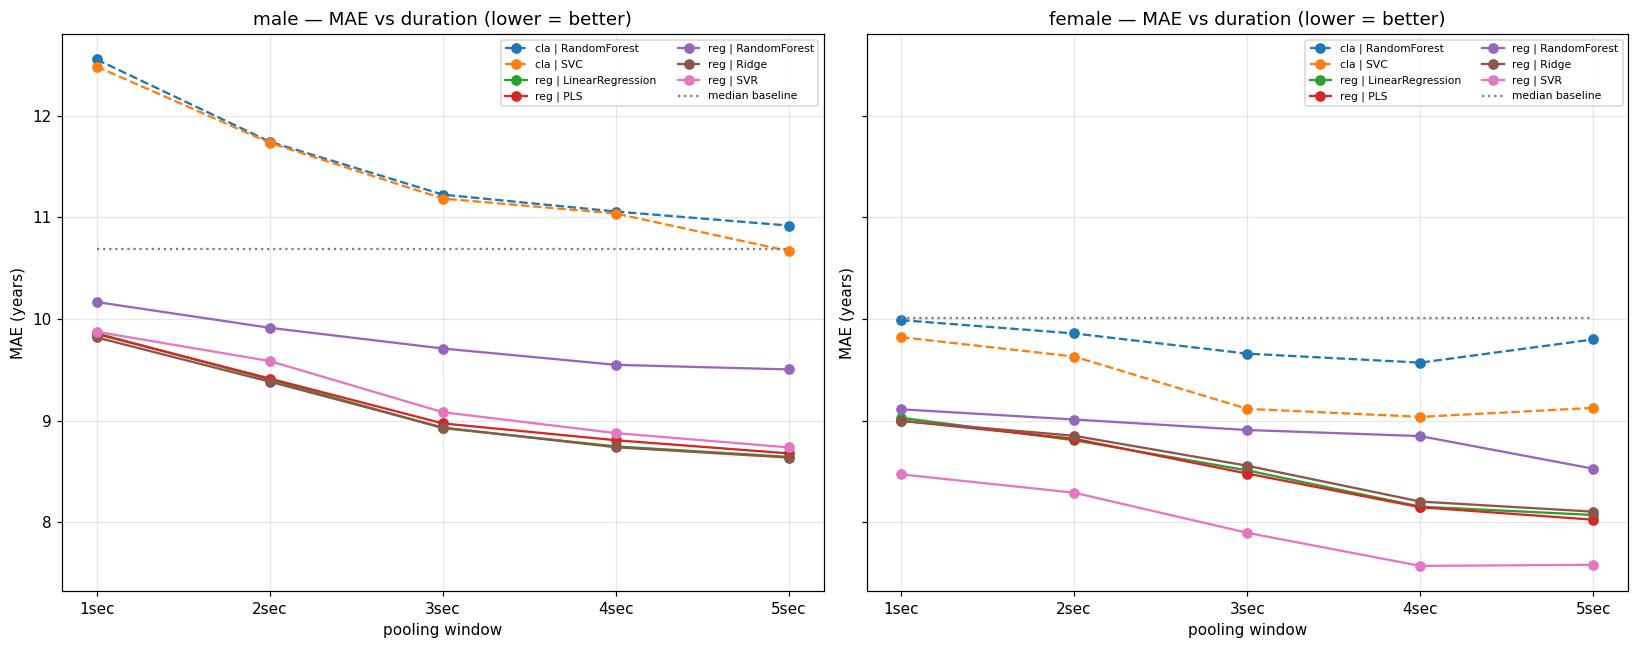

In [9]:
x_positions = np.arange(len(DURATIONS))
duration_labels = list(DURATIONS)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
cmap = plt.cm.tab10

for ax, gender in zip(axes, ["male", "female"]):
    gender_df = results[results["gender"] == gender]
    model_names = [name for name in gender_df["model"].unique() if name != "median-baseline"]
    combos = (gender_df[gender_df["model"] != "median-baseline"]
        [["framing", "model"]].drop_duplicates()
        .sort_values(["framing", "model"]))
    for color_idx, (framing, model_name) in enumerate(combos.itertuples(index=False)):
        model_rows = gender_df[(gender_df["framing"] == framing) &
                             (gender_df["model"] == model_name)]
        mae_by_duration = model_rows.set_index("duration").reindex(duration_labels)["MAE"]
        ax.plot(x_positions, mae_by_duration.values, marker="o", color=cmap(color_idx % 10),
              ls="--" if framing == "classification" else "-",
              label=f"{framing[:3]} | {model_name}")



    baseline = (gender_df[gender_df["model"] == "median-baseline"]
                .set_index("duration").reindex(duration_labels)["MAE"])
    ax.plot(x_positions, baseline.values, ls=":", color="grey", lw=1.5, label="median baseline")

    ax.set_xticks(x_positions); ax.set_xticklabels(duration_labels)
    ax.set_title(f"{gender} — MAE vs duration (lower = better)")
    ax.set_xlabel("pooling window"); ax.set_ylabel("MAE (years)")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 8. results



In [10]:
out = ROOT / "cls_compare_results.csv"
results.round(4).to_csv(out, index=False)
print(f"saved -> {out}  ({len(results)} rows)")

saved_models = sorted(MODELS_DIR.glob("*.joblib"))
print(f"fitted models cached in {MODELS_DIR}/ : {len(saved_models)} files")
for model_path in saved_models:
    print("   ", model_path.name)

saved -> cls_compare_results.csv  (80 rows)
fitted models cached in cls_compare_models/ : 88 files
    cls_1sec_female_RandomForest.joblib
    cls_1sec_female_SVC.joblib
    cls_1sec_male_RandomForest.joblib
    cls_1sec_male_SVC.joblib
    cls_2sec_female_RandomForest.joblib
    cls_2sec_female_SVC.joblib
    cls_2sec_male_RandomForest.joblib
    cls_2sec_male_SVC.joblib
    cls_3sec_female_RandomForest.joblib
    cls_3sec_female_SVC.joblib
    cls_3sec_male_RandomForest.joblib
    cls_3sec_male_SVC.joblib
    cls_4sec_female_RandomForest.joblib
    cls_4sec_female_SVC.joblib
    cls_4sec_male_RandomForest.joblib
    cls_4sec_male_SVC.joblib
    cls_5sec_female_RandomForest.joblib
    cls_5sec_female_SVC.joblib
    cls_5sec_male_RandomForest.joblib
    cls_5sec_male_SVC.joblib
    cls_female_KNN.joblib
    cls_female_RandomForest.joblib
    cls_female_SVC.joblib
    cls_male_KNN.joblib
    cls_male_RandomForest.joblib
    cls_male_SVC.joblib
    reg_1sec_female_LinearRegression.joblib